In [27]:
import time

import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('pgf.mplstyle')
plt.rcParams.update({
    "pgf.preamble": "\n".join([
        r"\usepackage{newpxmath}",
        r"\usepackage{newpxtext}",
    ]),
})

from qpotts import PottsModel, Start

FIG_PATH = '../results/'


In [34]:
L=1000
q=5

In [ ]:
def curie_temp(q: int):
    return 1 / (np.log(1 + np.sqrt(q)))

def state(L, T, q, ax):
    pm = PottsModel(L, T, q, Start.Cold)
    pm.sample_metropolis(0, 500_000_000)
    ax.imshow(pm.state_view())
    return pm.state_view().copy()

Elapsed time: 45.87s


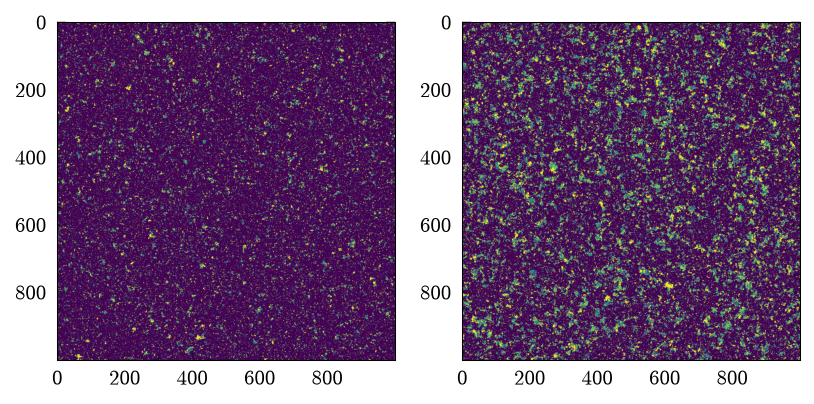

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(6,3), dpi=150)

start_time = time.perf_counter()

plot_state(L, curie_temp(q)-1e-2, q, ax[0])
plot_state(L, curie_temp(q)+1e-2, q, ax[1])

end_time = time.perf_counter()
print(f"Elapsed time: {end_time-start_time:.2f}s")